In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [4]:
DATASET_PATH = Path(
    "/Users/bhavaykhatri/Desktop/embeddings/openSMILE/"
    "singBAP_dataset_opensmile-compare-2016_3.0s.parquet"
)

OUTPUT_DIR = Path(
    "/Users/bhavaykhatri/Desktop/opensmile_compare_2016/"
    "opensmile_3.0s_lda"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_EXPERIENCE = [
    "intermediate",
    "professional",
]

TARGET_CLASSES = [
    "correct",
    "arched_back",
    "hunched_back",
    "sideways",
    "chest_breathing",
    "over_articulation",
    "under_articulation",
]

if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found:\n{DATASET_PATH}"
    )

df = pd.read_parquet(DATASET_PATH)

df = df[
    df["experience"].isin(TARGET_EXPERIENCE)
    & df["condition"].isin(TARGET_CLASSES)
].copy()

df = df.reset_index(drop=True)

print("Filtered shape:", df.shape)

display(
    df["condition"]
    .value_counts()
    .reindex(TARGET_CLASSES)
    .rename_axis("Condition")
    .to_frame("Samples")
)

Filtered shape: (3438, 13)


,Samples
Condition,
correct,638
arched_back,405
hunched_back,556
sideways,521
chest_breathing,512
over_articulation,411
under_articulation,395


In [5]:
def decode_embedding(value):
    if isinstance(
        value,
        (bytes, bytearray, memoryview),
    ):
        return np.frombuffer(
            value,
            dtype=np.float32,
        ).copy()

    return np.asarray(
        value,
        dtype=np.float32,
    ).reshape(-1)


decoded_embeddings = df["embedding"].map(
    decode_embedding
)

embedding_lengths = decoded_embeddings.map(len)

print(
    "Embedding dimensions found:",
    sorted(embedding_lengths.unique())
)

valid_length_rows = (
    embedding_lengths == 6373
)

if not valid_length_rows.all():
    print(
        "Rows removed due to unexpected length:",
        int((~valid_length_rows).sum()),
    )

    df = df.loc[
        valid_length_rows
    ].reset_index(drop=True)

    decoded_embeddings = decoded_embeddings.loc[
        valid_length_rows
    ]


X = np.vstack(
    decoded_embeddings.to_numpy()
).astype(
    np.float32,
    copy=False,
)

y = (
    df["condition"]
    .astype(str)
    .to_numpy()
)

valid_rows = np.isfinite(X).all(axis=1)

print(
    "Rows removed due to NaN or infinity:",
    int((~valid_rows).sum()),
)

X = X[valid_rows]
y = y[valid_rows]

df = df.loc[
    valid_rows
].reset_index(drop=True)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

assert X.shape[1] == 6373

Embedding dimensions found: [6373]
Rows removed due to NaN or infinity: 0
X shape: (3438, 6373)
y shape: (3438,)
Classes: ['arched_back' 'chest_breathing' 'correct' 'hunched_back'
 'over_articulation' 'sideways' 'under_articulation']


In [6]:
lda = LinearDiscriminantAnalysis(
    n_components=3,
    solver="svd",
)

X_lda = lda.fit_transform(
    X,
    y,
)

print("Original shape:", X.shape)
print("LDA shape:", X_lda.shape)

print(
    "Explained discriminant ratios:",
    lda.explained_variance_ratio_,
)

print(
    "First three cumulative ratio:",
    lda.explained_variance_ratio_.sum(),
)

Original shape: (3438, 6373)
LDA shape: (3438, 3)
Explained discriminant ratios: [0.9942754  0.00143379 0.00140682]
First three cumulative ratio: 0.997116


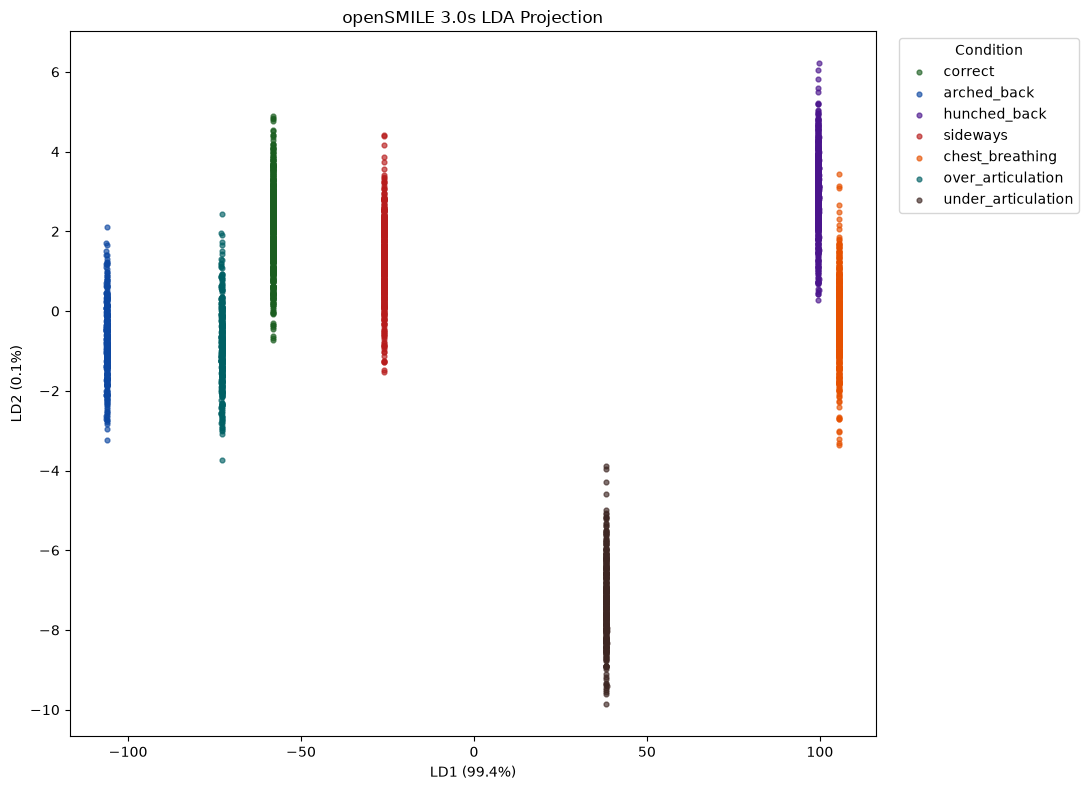

In [7]:
DARK_COLORS = {
    "correct": "#1B5E20",
    "arched_back": "#0D47A1",
    "hunched_back": "#4A148C",
    "sideways": "#B71C1C",
    "chest_breathing": "#E65100",
    "over_articulation": "#006064",
    "under_articulation": "#3E2723",
}

plt.figure(figsize=(11, 8))

for class_name in TARGET_CLASSES:
    class_mask = y == class_name

    plt.scatter(
        X_lda[class_mask, 0],
        X_lda[class_mask, 1],
        s=12,
        alpha=0.65,
        color=DARK_COLORS[class_name],
        label=class_name,
    )

plt.xlabel(
    f"LD1 "
    f"({lda.explained_variance_ratio_[0] * 100:.1f}%)"
)

plt.ylabel(
    f"LD2 "
    f"({lda.explained_variance_ratio_[1] * 100:.1f}%)"
)

plt.title(
    "openSMILE 3.0s LDA Projection"
)

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "opensmile_3.0s_lda_2d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

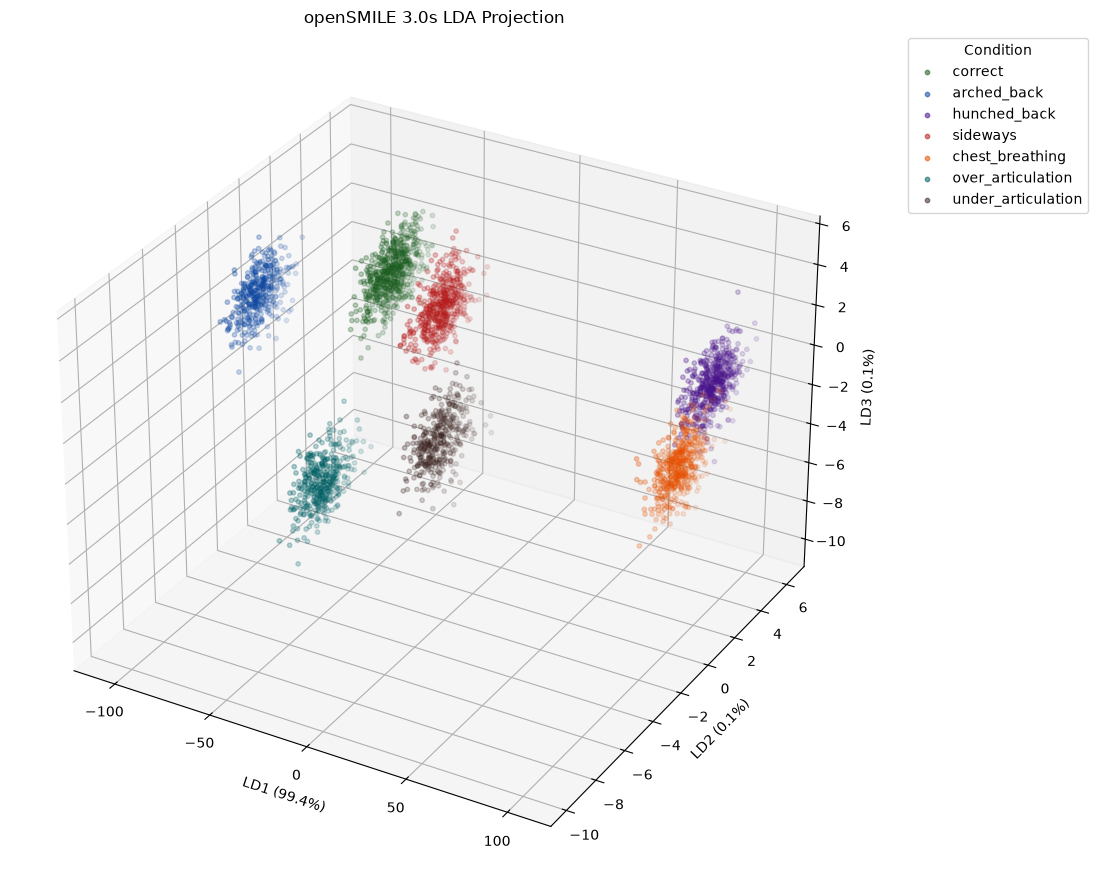

In [8]:
fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

for class_name in TARGET_CLASSES:
    class_mask = y == class_name

    ax.scatter(
        X_lda[class_mask, 0],
        X_lda[class_mask, 1],
        X_lda[class_mask, 2],
        s=10,
        alpha=0.55,
        color=DARK_COLORS[class_name],
        label=class_name,
    )

ax.set_xlabel(
    f"LD1 "
    f"({lda.explained_variance_ratio_[0] * 100:.1f}%)"
)

ax.set_ylabel(
    f"LD2 "
    f"({lda.explained_variance_ratio_[1] * 100:.1f}%)"
)

ax.set_zlabel(
    f"LD3 "
    f"({lda.explained_variance_ratio_[2] * 100:.1f}%)"
)

ax.set_title(
    "openSMILE 3.0s LDA Projection"
)

ax.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "opensmile_3.0s_lda_3d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [9]:
lda_results = pd.DataFrame({
    "LD1": X_lda[:, 0],
    "LD2": X_lda[:, 1],
    "LD3": X_lda[:, 2],
    "condition": y,
})

if "experience" in df.columns:
    lda_results["experience"] = (
        df["experience"]
        .astype(str)
        .to_numpy()
    )

if "filename" in df.columns:
    lda_results["filename"] = (
        df["filename"]
        .astype(str)
        .to_numpy()
    )

lda_results.to_csv(
    OUTPUT_DIR
    / "opensmile_3.0s_lda_coordinates.csv",
    index=False,
)

print(
    "Saved outputs to:",
    OUTPUT_DIR.resolve(),
)

Saved outputs to: /Users/bhavaykhatri/Desktop/opensmile_compare_2016/opensmile_3.0s_lda
